In [1]:
# =========================
# NOTEBOOK 2: BIOLOGICAL INTERPRETATION OF LOCKED 10-METABOLITE PANEL
# =========================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.special import expit

BASE = "../.."

META_PATH = f"{BASE}/data/metadata/Metadata_061523.csv"
METAB_PATH = f"{BASE}/data/metabolomics/Metabolomics_maaslined_norun.csv"

OUT_DIR = f"{BASE}/output/locked_panel_biology"
os.makedirs(OUT_DIR, exist_ok=True)

LOCKED_PANEL = [
    "1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)",
    "N-acetylglutamate",
    "N4-acetylcytidine",
    "sphingomyelin (d18:1/24:1, d18:2/24:0)*",
    "1-methylurate",
    "N-palmitoyl-sphingosine (d18:1/16:0)",
    "3-(4-hydroxyphenyl)lactate",
    "N-acetylglucosamine/N-acetylgalactosamine",
    "vanillylmandelate (VMA)",
    "4-vinylguaiacol sulfate"
]

# =========================
# LOAD DATA
# =========================

meta_raw = pd.read_csv(META_PATH)
metab_raw = pd.read_csv(METAB_PATH)

metab = (
    metab_raw
    .set_index("Unnamed: 0")
    .T
    .reset_index()
    .rename(columns={"index": "sample_id"})
)

metab["participant_id"] = metab["sample_id"].str.replace(r"_tp\d+$", "", regex=True)
metab["timepoint"] = metab["sample_id"].str.extract(r"_tp(\d+)")

tp1 = metab[metab["timepoint"] == "1"].copy()

meta_raw["participant_id"] = meta_raw["samples_id"].astype(str)
meta_tp1 = meta_raw[meta_raw["timepoints"] == "tp1"].copy()

df = tp1.merge(meta_tp1, on="participant_id", how="inner")

y = df["study_ptorhc"].map({"MECFS": 1, "Control": 0})

X_panel = df[LOCKED_PANEL].apply(pd.to_numeric, errors="coerce")

print("Panel data:", X_panel.shape)
print("Class counts:", y.value_counts().to_dict())
print("Missing:", X_panel.isna().sum().sum())

Panel data: (214, 10)
Class counts: {1: 135, 0: 79}
Missing: 0


In [2]:
# =========================
# COMPUTE ME/CFS METABOLITE SCORE
# =========================

score_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        C=1.0,
        max_iter=5000,
        random_state=42
    ))
])

score_model.fit(X_panel, y)

score_probs = score_model.predict_proba(X_panel)[:, 1]

score_df = df[["participant_id", "study_ptorhc"]].copy()
score_df["label"] = y.values
score_df["mecfs_score"] = score_probs

display(score_df.head())

score_df.to_csv(f"{OUT_DIR}/mecfs_metabolite_scores.csv", index=False)

,participant_id,study_ptorhc,label,mecfs_score
0,SAM000269,MECFS,1,0.636568
1,SAM000268,MECFS,1,0.740155
2,SAM000266,MECFS,1,0.516147
3,SAM000257,Control,0,0.100672
4,SAM000260,MECFS,1,0.868054


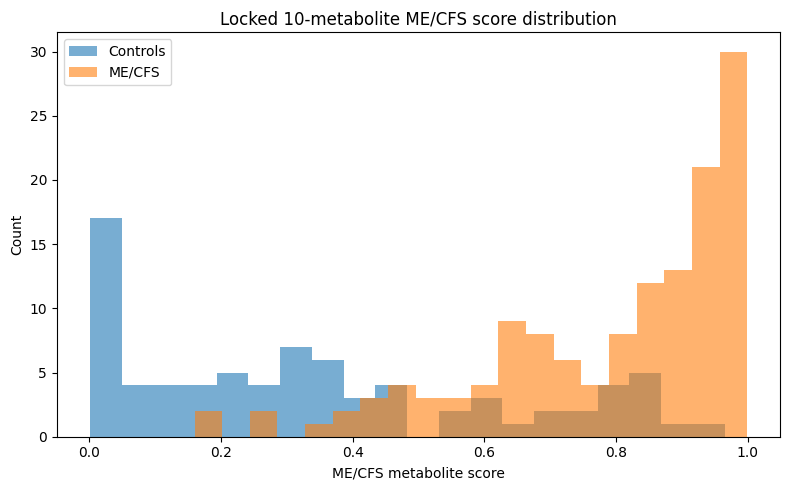

In [3]:
# =========================
# SCORE DISTRIBUTION
# =========================

plt.figure(figsize=(8,5))

plt.hist(
    score_df.loc[score_df["label"] == 0, "mecfs_score"],
    bins=20,
    alpha=0.6,
    label="Controls"
)

plt.hist(
    score_df.loc[score_df["label"] == 1, "mecfs_score"],
    bins=20,
    alpha=0.6,
    label="ME/CFS"
)

plt.xlabel("ME/CFS metabolite score")
plt.ylabel("Count")
plt.title("Locked 10-metabolite ME/CFS score distribution")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/mecfs_score_distribution.png", dpi=300)
plt.show()

In [6]:
# Inspect metadata and QUEST columns

import pandas as pd
import os

BASE = "../.."

meta = pd.read_csv(f"{BASE}/data/metadata/Metadata_061523.csv")
quest = pd.read_csv(f"{BASE}/data/quest_lab/Quest_lab_maaslined.csv")

print("Metadata shape:", meta.shape)
print("Quest shape:", quest.shape)

print("\nMetadata columns:")
for c in meta.columns:
    print(c)

print("\nQuest columns:")
for c in quest.columns:
    print(c)

Metadata shape: (515, 22)
Quest shape: (37, 504)

Metadata columns:
Unnamed: 0
sample_id_tp1
samples_id
timepoints
study_ptorhc
illness_duration
age
age_group
gender
bmi
ethnic
race
diet_meat
diet_sugar
diet_veg
diet_grains
diet_fruit
antifungals
antibiotics
probiotics
antivirals
IBS

Quest columns:
Unnamed: 0
SAM000201_tp1
SAM000201_tp2
SAM000201_tp3
SAM000201_tp4
SAM000202_tp1
SAM000202_tp2
SAM000202_tp3
SAM000202_tp4
SAM000203_tp1
SAM000203_tp2
SAM000206_tp1
SAM000207_tp1
SAM000208_tp1
SAM000208_tp2
SAM000210_tp1
SAM000210_tp2
SAM000237_tp1
SAM000212_tp1
SAM000212_tp2
SAM000212_tp3
SAM000212_tp4
SAM000214_tp1
SAM000214_tp2
SAM000214_tp3
SAM000216_tp1
SAM000216_tp3
SAM000221_tp1
SAM000222_tp1
SAM000222_tp2
SAM000223_tp1
SAM000223_tp2
SAM000224_tp1
SAM000226_tp1
SAM000226_tp2
SAM000240_tp1
SAM000240_tp2
SAM000240_tp3
SAM000240_tp4
SAM000241_tp1
SAM000241_tp2
SAM000242_tp1
SAM000242_tp2
SAM000236_tp1
SAM000236_tp2
SAM000243_tp1
SAM000243_tp2
SAM000213_tp1
SAM000213_tp2
SAM000245_tp1
SA

In [7]:
# Merge ME/CFS metabolite score with metadata

score_meta = score_df.merge(
    meta,
    left_on="participant_id",
    right_on="samples_id",
    how="left"
)

print(score_meta.shape)
display(score_meta.head())

(214, 26)


,participant_id,study_ptorhc_x,label,mecfs_score,Unnamed: 0,sample_id_tp1,samples_id,timepoints,study_ptorhc_y,illness_duration,...,diet_meat,diet_sugar,diet_veg,diet_grains,diet_fruit,antifungals,antibiotics,probiotics,antivirals,IBS
0,SAM000269,MECFS,1,0.636568,SAM000269_tp1,SAM000269,SAM000269,tp1,MECFS,Long,...,2.0,4.0,2.0,4.0,3.0,No,No,No,No,2.0
1,SAM000268,MECFS,1,0.740155,SAM000268_tp1,SAM000268,SAM000268,tp1,MECFS,Short,...,2.0,2.0,3.0,4.0,4.0,No,No,No,No,1.0
2,SAM000266,MECFS,1,0.516147,SAM000266_tp1,SAM000266,SAM000266,tp1,MECFS,Short,...,3.0,4.0,2.0,1.0,2.0,No,No,No,No,3.0
3,SAM000257,Control,0,0.100672,SAM000257_tp1,SAM000257,SAM000257,tp1,Control,Control,...,1.0,4.0,3.0,2.0,4.0,No,No,No,No,NaN
4,SAM000260,MECFS,1,0.868054,SAM000260_tp1,SAM000260,SAM000260,tp1,MECFS,Short,...,3.0,3.0,4.0,1.0,3.0,No,No,No,No,3.0


In [8]:
# Find numeric metadata columns correlated with metabolite score

numeric_cols = score_meta.select_dtypes(include="number").columns.tolist()

rows = []

for c in numeric_cols:
    if c in ["label", "mecfs_score"]:
        continue
    
    temp = score_meta[["mecfs_score", c]].dropna()
    
    if len(temp) > 20:
        corr = temp["mecfs_score"].corr(temp[c], method="spearman")
        rows.append({
            "variable": c,
            "spearman_corr_with_score": corr,
            "n": len(temp)
        })

corr_df = pd.DataFrame(rows).sort_values(
    "spearman_corr_with_score",
    key=abs,
    ascending=False
)

display(corr_df.head(30))

,variable,spearman_corr_with_score,n
0,age,0.142699,214
1,bmi,0.111726,177
5,diet_grains,-0.107235,211
7,IBS,0.089789,134
4,diet_veg,-0.089506,211
6,diet_fruit,0.078242,211
2,diet_meat,0.026525,211
3,diet_sugar,0.001617,211


In [ ]:
# Compare metabolite model vs metadata-only model vs combined model

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

candidate_meta_cols = [
    c for c in ["age", "bmi", "sex", "gender"]
    if c in score_meta.columns
]

print("Candidate metadata columns:", candidate_meta_cols)

Candidate metadata columns: ['age', 'bmi', 'gender']


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

meta_cols = ["age", "bmi", "gender"]

meta_df = score_meta[meta_cols].copy()

numeric_meta = ["age", "bmi"]
categorical_meta = ["gender"]

preprocess_meta = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_meta),
    
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), categorical_meta)
])

meta_model = Pipeline([
    ("preprocess", preprocess_meta),
    ("logreg", LogisticRegression(max_iter=5000))
])

meta_model.fit(meta_df, y)

meta_probs = meta_model.predict_proba(meta_df)[:, 1]

print("Metadata-only AUC:", roc_auc_score(y, meta_probs))

print("\nMissing values:")
print(meta_df.isna().sum())

Metadata-only AUC: 0.630098452883263

Missing values:
age        0
bmi       37
gender     0
dtype: int64


In [ ]:
# =========================
# COMBINED MODEL: LOCKED 10 METABOLITES + AGE/BMI/GENDER
# =========================

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import pandas as pd

# locked metabolites
metab_part = X_panel[LOCKED_PANEL].copy()

# metadata
meta_part = score_meta[["age", "bmi", "gender"]].copy()

combined_X = pd.concat(
    [metab_part, meta_part],
    axis=1
)

numeric_cols = LOCKED_PANEL + ["age", "bmi"]
categorical_cols = ["gender"]

preprocess_combined = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_cols),
    
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), categorical_cols)
])

combined_model = Pipeline([
    ("preprocess", preprocess_combined),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

combined_auc = cross_val_score(
    combined_model,
    combined_X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Combined model CV AUC:")
print("Mean:", combined_auc.mean())
print("Std:", combined_auc.std())

combined_model.fit(combined_X, y)
combined_probs = combined_model.predict_proba(combined_X)[:, 1]

print("\nCombined apparent full-data AUC:")
print(roc_auc_score(y, combined_probs))

Combined model CV AUC:
Mean: 0.8360802469135802
Std: 0.05574969508215075

Combined apparent full-data AUC:
0.8941397093295828


In [13]:
import os, re, itertools, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression

BASE = "../.."

LOCKED_PANEL = [
    "1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)",
    "N-acetylglutamate",
    "N4-acetylcytidine",
    "sphingomyelin (d18:1/24:1, d18:2/24:0)*",
    "1-methylurate",
    "N-palmitoyl-sphingosine (d18:1/16:0)",
    "3-(4-hydroxyphenyl)lactate",
    "N-acetylglucosamine/N-acetylgalactosamine",
    "vanillylmandelate (VMA)",
    "4-vinylguaiacol sulfate"
]

# =========================
# HELPERS
# =========================

def strip_tp(x):
    return re.sub(r"_tp\d+$", "", str(x))

def get_tp(x):
    m = re.search(r"_tp(\d+)$", str(x))
    return m.group(1) if m else np.nan

def load_transposed_omics(path, prefix):
    raw = pd.read_csv(path)
    feature_col = raw.columns[0]

    mat = (
        raw
        .set_index(feature_col)
        .T
        .reset_index()
        .rename(columns={"index": "sample_id"})
    )

    mat["participant_id"] = mat["sample_id"].apply(strip_tp)
    mat["tp"] = mat["sample_id"].apply(get_tp)

    # keep tp1 if timepoints exist
    if mat["tp"].notna().any():
        mat = mat[mat["tp"] == "1"].copy()

    mat = mat.drop(columns=["sample_id", "tp"], errors="ignore")
    mat = mat.set_index("participant_id")

    mat = mat.apply(pd.to_numeric, errors="coerce")
    mat = mat.loc[:, mat.notna().mean() > 0.80]  # keep mostly complete features

    mat.columns = [f"{prefix}__{c}" for c in mat.columns]
    return mat

# =========================
# LOAD METADATA LABELS
# =========================

meta = pd.read_csv(f"{BASE}/data/metadata/Metadata_061523.csv")
meta["participant_id"] = meta["samples_id"].astype(str)
meta_tp1 = meta[meta["timepoints"] == "tp1"].copy()

label_df = meta_tp1[["participant_id", "study_ptorhc"]].drop_duplicates()
label_df["y"] = label_df["study_ptorhc"].map({"MECFS": 1, "Control": 0})
label_df = label_df.dropna(subset=["y"]).copy()
label_df["y"] = label_df["y"].astype(int)
label_df = label_df.set_index("participant_id")

# =========================
# BUILD MODALITIES
# =========================

modalities = {}

# locked metabolite panel
metab_all = load_transposed_omics(
    f"{BASE}/data/metabolomics/Metabolomics_maaslined_norun.csv",
    "metab"
)

locked_cols = [f"metab__{m}" for m in LOCKED_PANEL]
modalities["locked_metab10"] = metab_all[locked_cols].copy()

# metadata covariates
meta_cov = meta_tp1.set_index("participant_id")[["age", "bmi", "gender"]].copy()
meta_cov = pd.get_dummies(meta_cov, columns=["gender"], drop_first=True)
modalities["metadata"] = meta_cov.apply(pd.to_numeric, errors="coerce")

# quest
modalities["quest"] = load_transposed_omics(
    f"{BASE}/data/quest_lab/Quest_lab_maaslined.csv",
    "quest"
)

# immune
modalities["immune_percentage"] = load_transposed_omics(
    f"{BASE}/data/immuno/immune_percentage.csv",
    "immune_pct"
)

modalities["immune_residue"] = load_transposed_omics(
    f"{BASE}/data/immuno/Immune_residue.csv",
    "immune_res"
)

# metagenomics candidates
possible_microbiome = {
    "kegg": f"{BASE}/data/metagenomics/KEGG_maaslined.csv",
    "species": f"{BASE}/data/metagenomics/Specie_abundance_maaslined.csv",
}

for name, path in possible_microbiome.items():
    if os.path.exists(path):
        modalities[name] = load_transposed_omics(path, name)

print("Loaded modalities:")
for name, Xmod in modalities.items():
    print(name, Xmod.shape)

# =========================
# TEST COMBINATIONS
# =========================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []

modality_names = list(modalities.keys())

for r in range(1, min(4, len(modality_names)) + 1):  # test 1-, 2-, 3-, 4-way combos
    for combo in itertools.combinations(modality_names, r):

        X_combo = pd.concat([modalities[m] for m in combo], axis=1)
        data = X_combo.join(label_df["y"], how="inner").dropna(subset=["y"])

        Xc = data.drop(columns=["y"])
        yc = data["y"].astype(int)

        # skip tiny / one-class combos
        if len(yc) < 50 or yc.nunique() < 2:
            continue

        k = min(50, Xc.shape[1])

        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("select", SelectKBest(score_func=f_classif, k=k)),
            ("logreg", LogisticRegression(
                penalty="l2",
                solver="liblinear",
                C=1.0,
                max_iter=5000,
                random_state=42
            ))
        ])

        aucs = cross_val_score(
            model,
            Xc,
            yc,
            cv=cv,
            scoring="roc_auc",
            n_jobs=-1
        )

        rows.append({
            "modalities": " + ".join(combo),
            "n_subjects": len(yc),
            "n_features": Xc.shape[1],
            "selected_k": k,
            "mean_cv_auc": aucs.mean(),
            "std_cv_auc": aucs.std()
        })

combo_results = (
    pd.DataFrame(rows)
    .sort_values("mean_cv_auc", ascending=False)
    .reset_index(drop=True)
)

display(combo_results.head(30))

combo_results.to_csv(
    f"{BASE}/output/modality_combination_auc_results.csv",
    index=False
)

Loaded modalities:
locked_metab10 (215, 10)
metadata (249, 3)
quest (242, 37)
immune_percentage (239, 311)
immune_residue (239, 311)
kegg (238, 4429)
species (238, 118)


,modalities,n_subjects,n_features,selected_k,mean_cv_auc,std_cv_auc
0,locked_metab10 + quest + immune_residue + species,235,476,50,0.865720,0.052443
1,locked_metab10 + quest + immune_percentage + s...,235,476,50,0.864616,0.044743
2,locked_metab10 + quest + immune_percentage + i...,235,669,50,0.855623,0.049539
3,locked_metab10 + quest + immune_residue,235,358,50,0.853852,0.035720
4,locked_metab10 + quest + immune_percentage,235,358,50,0.852531,0.051324
5,locked_metab10,214,10,10,0.849043,0.065807
6,locked_metab10 + quest + species,235,165,50,0.843624,0.034734
7,locked_metab10 + metadata + quest + immune_res...,249,361,50,0.832601,0.070910
8,locked_metab10 + immune_residue + species,234,439,50,0.826793,0.064752
9,locked_metab10 + quest,235,47,47,0.821731,0.051315


In [14]:
# =========================
# BUILD ONE MULTI-OMICS MATRIX
# =========================

all_modalities = pd.concat([
    modalities["locked_metab10"],      # or full metabolomics if you want
    modalities["quest"],
    modalities["immune_percentage"],
    modalities["immune_residue"],
    modalities["species"],
    modalities["metadata"]
], axis=1)

multi_df = all_modalities.join(
    label_df["y"],
    how="inner"
)

X_multi = multi_df.drop(columns=["y"])
y_multi = multi_df["y"]

print(X_multi.shape)

(249, 790)


In [15]:
from collections import Counter
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

C_GRID = [0.01, 0.03, 0.06, 0.1, 0.3]

selection_counts = Counter()

N_REPEATS = 20

for repeat in range(N_REPEATS):

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42 + repeat
    )

    for train_idx, _ in cv.split(X_multi, y_multi):

        X_fold = X_multi.iloc[train_idx]
        y_fold = y_multi.iloc[train_idx]

        for C in C_GRID:

            model = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("lasso", LogisticRegression(
                    penalty="l1",
                    solver="liblinear",
                    C=C,
                    max_iter=5000,
                    random_state=42
                ))
            ])

            model.fit(X_fold, y_fold)

            coef = model.named_steps["lasso"].coef_[0]

            selected = X_multi.columns[coef != 0]

            for feat in selected:
                selection_counts[feat] += 1

In [16]:
stability_df = pd.DataFrame({
    "feature": selection_counts.keys(),
    "count": selection_counts.values()
})

stability_df["frequency"] = (
    stability_df["count"] / (20 * 5 * len(C_GRID))
)

stability_df = stability_df.sort_values(
    "frequency",
    ascending=False
)

display(stability_df.head(50))

,feature,count,frequency
0,quest__Vitamin B12,375,0.750
1,metab__N-acetylglutamate,301,0.602
12,species__Dysosmobacter_welbionis,300,0.600
2,metab__N4-acetylcytidine,293,0.586
5,metab__N-palmitoyl-sphingosine (d18:1/16:0),291,0.582
6,metab__3-(4-hydroxyphenyl)lactate,291,0.582
13,species__GGB1266_SGB1699,287,0.574
3,"metab__sphingomyelin (d18:1/24:1, d18:2/24:0)*",286,0.572
7,metab__vanillylmandelate (VMA),273,0.546
4,metab__1-methylurate,259,0.518


Using modalities:
- locked_metab10 (215, 10)
- metadata (249, 3)
- quest (242, 37)
- immune_percentage (239, 311)
- immune_residue (239, 311)
- species (238, 118)

Multi-omics matrix: (249, 790)
Class counts: {1: 153, 0: 96}
Train: (199, 790) {1: 122, 0: 77}
Test: (50, 790) {1: 31, 0: 19}

===== TOP 50 MULTI-OMICS CONSENSUS FEATURES =====


,feature,count,frequency,rank,modality
0,quest__Vitamin B12,299,0.427143,1,quest
1,species__Dysosmobacter_welbionis,295,0.421429,2,species
2,metab__1-stearoyl-2-docosahexaenoyl-GPC (18:0/...,278,0.397143,3,metab
3,metab__N-palmitoyl-sphingosine (d18:1/16:0),276,0.394286,4,metab
4,metab__N-acetylglutamate,265,0.378571,5,metab
5,metab__3-(4-hydroxyphenyl)lactate,263,0.375714,6,metab
6,species__GGB1266_SGB1699,259,0.370000,7,species
7,metab__1-methylurate,257,0.367143,8,metab
8,metab__N4-acetylcytidine,256,0.365714,9,metab
9,"metab__sphingomyelin (d18:1/24:1, d18:2/24:0)*",229,0.327143,10,metab



Top feature modalities:


species       15
immune_pct    12
immune_res    11
metab          9
quest          3
Name: modality, dtype: int64


===== MULTI-OMICS PANEL SIZE CV RESULTS =====


,panel_size,mean_train_cv_auc,std_train_cv_auc
0,5,0.809844,0.042131
1,10,0.872006,0.054973
2,15,0.936035,0.034197
3,20,0.951117,0.017984
4,30,0.960270,0.015156
5,50,0.957223,0.030324



===== LOCKED MULTI-OMICS PANEL =====
Panel size: 15
Train CV AUC: 0.9360354166666667 +/- 0.03419661010043405
- quest__Vitamin B12
- species__Dysosmobacter_welbionis
- metab__1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)
- metab__N-palmitoyl-sphingosine (d18:1/16:0)
- metab__N-acetylglutamate
- metab__3-(4-hydroxyphenyl)lactate
- species__GGB1266_SGB1699
- metab__1-methylurate
- metab__N4-acetylcytidine
- metab__sphingomyelin (d18:1/24:1, d18:2/24:0)*
- metab__N-acetylglucosamine/N-acetylgalactosamine
- metab__vanillylmandelate (VMA)
- species__Phocaeicola_plebeius
- immune_res__% CD4+ CD161+ Va7.2- d6
- immune_pct__CD8+ DN+ MAIT % RO- CD27- d0

===== MULTI-OMICS HELD-OUT TEST PERFORMANCE =====
AUC: 0.8251273344651952
Accuracy: 0.76
Balanced accuracy: 0.7249575551782683

Confusion matrix:
[[11  8]
 [ 4 27]]

Classification report:
              precision    recall  f1-score   support

           0       0.73      0.58      0.65        19
           1       0.77      0.87      0.82      

metab__vanillylmandelate (VMA)                        -1.019425
species__GGB1266_SGB1699                              -1.011271
metab__N4-acetylcytidine                               0.979363
species__Phocaeicola_plebeius                         -0.920002
species__Dysosmobacter_welbionis                       0.898680
metab__sphingomyelin (d18:1/24:1, d18:2/24:0)*         0.892619
immune_pct__CD8+ DN+ MAIT % RO- CD27- d0               0.873070
metab__N-acetylglutamate                               0.827285
immune_res__% CD4+ CD161+ Va7.2- d6                    0.779194
quest__Vitamin B12                                     0.770867
metab__N-palmitoyl-sphingosine (d18:1/16:0)            0.633110
metab__1-methylurate                                  -0.629563
metab__3-(4-hydroxyphenyl)lactate                     -0.559898
metab__N-acetylglucosamine/N-acetylgalactosamine       0.462149
metab__1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)    0.266656
dtype: float64


===== MULTI-OMICS ROBUSTNESS SUMMARY =====


,panel_size,train_cv_auc_mean,train_cv_auc_std,heldout_test_auc,heldout_test_accuracy,heldout_test_balanced_accuracy,mean_repeated_split_auc,median_repeated_split_auc,std_repeated_split_auc,min_repeated_split_auc,max_repeated_split_auc,features
0,15,0.936035,0.034197,0.825127,0.76,0.724958,0.90489,0.90747,0.041224,0.766553,0.974533,quest__Vitamin B12 | species__Dysosmobacter_we...


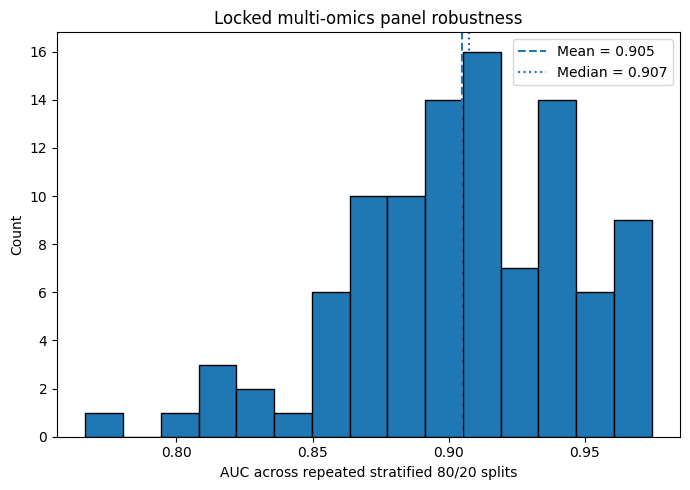


===== MODEL COMPARISON =====


,model,heldout_test_auc,notes
0,locked_10_metabolites,NaN,Original locked metabolite panel
1,multiomics_consensus_panel,0.825127,Consensus LASSO across available modalities


In [17]:
# =========================
# MULTI-OMICS CONSENSUS LASSO PIPELINE
# =========================

import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

BASE = "../.."
OUT_DIR = f"{BASE}/output/multiomics_consensus_lasso"
os.makedirs(OUT_DIR, exist_ok=True)

RANDOM_STATE = 42

# =========================
# BUILD FULL MULTI-OMICS MATRIX
# =========================

use_modalities = [
    "locked_metab10",
    "metadata",
    "quest",
    "immune_percentage",
    "immune_residue",
    "species"
]

available_modalities = [
    m for m in use_modalities
    if m in modalities
]

print("Using modalities:")
for m in available_modalities:
    print("-", m, modalities[m].shape)

X_multi = pd.concat(
    [modalities[m] for m in available_modalities],
    axis=1
)

multi_df = X_multi.join(label_df["y"], how="inner")
multi_df = multi_df.dropna(subset=["y"])

X_multi = multi_df.drop(columns=["y"])
y_multi = multi_df["y"].astype(int)

# remove columns with too much missingness
X_multi = X_multi.loc[:, X_multi.notna().mean() > 0.80]

print("\nMulti-omics matrix:", X_multi.shape)
print("Class counts:", y_multi.value_counts().to_dict())

# =========================
# SAME TRAIN/TEST SPLIT
# =========================

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi,
    y_multi,
    test_size=0.20,
    stratify=y_multi,
    random_state=RANDOM_STATE
)

print("Train:", X_train_m.shape, y_train_m.value_counts().to_dict())
print("Test:", X_test_m.shape, y_test_m.value_counts().to_dict())

# =========================
# CONSENSUS LASSO ON TRAIN ONLY
# =========================

C_GRID = [0.003, 0.006, 0.01, 0.03, 0.06, 0.1, 0.3]
N_REPEATS = 20
N_SPLITS = 5

counts = pd.Series(0, index=X_train_m.columns, dtype=int)

for repeat in range(N_REPEATS):
    
    cv = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE + repeat
    )
    
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train_m, y_train_m)):
        
        X_fold = X_train_m.iloc[tr_idx]
        y_fold = y_train_m.iloc[tr_idx]
        
        for C in C_GRID:
            
            model = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("lasso", LogisticRegression(
                    penalty="l1",
                    solver="liblinear",
                    C=C,
                    max_iter=5000,
                    random_state=RANDOM_STATE
                ))
            ])
            
            model.fit(X_fold, y_fold)
            
            coefs = model.named_steps["lasso"].coef_[0]
            selected = X_train_m.columns[coefs != 0]
            
            counts[selected] += 1

total_runs = N_REPEATS * N_SPLITS * len(C_GRID)

multi_stability = pd.DataFrame({
    "feature": counts.index,
    "count": counts.values,
    "frequency": counts.values / total_runs
}).sort_values(["count", "feature"], ascending=[False, True]).reset_index(drop=True)

multi_stability["rank"] = multi_stability.index + 1

def get_modality(feature):
    return feature.split("__")[0] if "__" in feature else "metadata"

multi_stability["modality"] = multi_stability["feature"].apply(get_modality)

print("\n===== TOP 50 MULTI-OMICS CONSENSUS FEATURES =====")
display(multi_stability.head(50))

multi_stability.to_csv(
    f"{OUT_DIR}/multiomics_consensus_feature_frequencies.csv",
    index=False
)

print("\nTop feature modalities:")
display(multi_stability.head(50)["modality"].value_counts())

# =========================
# PANEL SIZE OPTIMIZATION
# =========================

ordered_features = multi_stability["feature"].tolist()
panel_sizes = [5, 10, 15, 20, 30, 50]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

panel_results = []

for k in panel_sizes:
    
    feats = ordered_features[:k]
    
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            C=1.0,
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])
    
    aucs = cross_val_score(
        model,
        X_train_m[feats],
        y_train_m,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )
    
    panel_results.append({
        "panel_size": k,
        "mean_train_cv_auc": aucs.mean(),
        "std_train_cv_auc": aucs.std(),
        "features": feats
    })

panel_results_df = pd.DataFrame(panel_results)

print("\n===== MULTI-OMICS PANEL SIZE CV RESULTS =====")
display(panel_results_df[["panel_size", "mean_train_cv_auc", "std_train_cv_auc"]])

panel_results_df.to_csv(
    f"{OUT_DIR}/multiomics_panel_cv_results.csv",
    index=False
)

# =========================
# CHOOSE BEST TRADEOFF PANEL
# smallest panel with >=95% of best CV AUC and AUC >=0.85
# =========================

best_auc = panel_results_df["mean_train_cv_auc"].max()

eligible = panel_results_df[
    (panel_results_df["mean_train_cv_auc"] >= 0.95 * best_auc) &
    (panel_results_df["mean_train_cv_auc"] >= 0.85)
].copy()

if len(eligible) == 0:
    chosen = panel_results_df.sort_values(
        ["mean_train_cv_auc", "panel_size"],
        ascending=[False, True]
    ).iloc[0]
else:
    chosen = eligible.sort_values(
        ["panel_size", "mean_train_cv_auc"],
        ascending=[True, False]
    ).iloc[0]

MULTIOMICS_PANEL = chosen["features"]

print("\n===== LOCKED MULTI-OMICS PANEL =====")
print("Panel size:", chosen["panel_size"])
print("Train CV AUC:", chosen["mean_train_cv_auc"], "+/-", chosen["std_train_cv_auc"])

for f in MULTIOMICS_PANEL:
    print("-", f)

pd.Series(MULTIOMICS_PANEL, name="feature").to_csv(
    f"{OUT_DIR}/LOCKED_MULTIOMICS_PANEL.csv",
    index=False
)

# =========================
# HELD-OUT TEST EVALUATION
# =========================

final_multi_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        C=1.0,
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

final_multi_model.fit(X_train_m[MULTIOMICS_PANEL], y_train_m)

multi_test_probs = final_multi_model.predict_proba(
    X_test_m[MULTIOMICS_PANEL]
)[:, 1]

multi_test_preds = (multi_test_probs >= 0.5).astype(int)

multi_test_auc = roc_auc_score(y_test_m, multi_test_probs)
multi_test_acc = accuracy_score(y_test_m, multi_test_preds)
multi_test_bal_acc = balanced_accuracy_score(y_test_m, multi_test_preds)

print("\n===== MULTI-OMICS HELD-OUT TEST PERFORMANCE =====")
print("AUC:", multi_test_auc)
print("Accuracy:", multi_test_acc)
print("Balanced accuracy:", multi_test_bal_acc)
print("\nConfusion matrix:")
print(confusion_matrix(y_test_m, multi_test_preds))
print("\nClassification report:")
print(classification_report(y_test_m, multi_test_preds))

# =========================
# COEFFICIENTS
# =========================

multi_coef = pd.Series(
    final_multi_model.named_steps["logreg"].coef_[0],
    index=MULTIOMICS_PANEL
).sort_values(key=abs, ascending=False)

print("\n===== MULTI-OMICS COEFFICIENTS =====")
display(multi_coef)

multi_coef.to_csv(
    f"{OUT_DIR}/LOCKED_MULTIOMICS_PANEL_COEFFICIENTS.csv"
)

# =========================
# REPEATED SPLIT ROBUSTNESS
# =========================

multi_aucs = []

for seed in range(100):
    
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_multi,
        y_multi,
        test_size=0.20,
        stratify=y_multi,
        random_state=seed
    )
    
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            C=1.0,
            max_iter=5000,
            random_state=seed
        ))
    ])
    
    model.fit(X_tr[MULTIOMICS_PANEL], y_tr)
    probs = model.predict_proba(X_te[MULTIOMICS_PANEL])[:, 1]
    multi_aucs.append(roc_auc_score(y_te, probs))

multi_aucs = np.array(multi_aucs)

multi_summary = pd.DataFrame([{
    "panel_size": len(MULTIOMICS_PANEL),
    "train_cv_auc_mean": chosen["mean_train_cv_auc"],
    "train_cv_auc_std": chosen["std_train_cv_auc"],
    "heldout_test_auc": multi_test_auc,
    "heldout_test_accuracy": multi_test_acc,
    "heldout_test_balanced_accuracy": multi_test_bal_acc,
    "mean_repeated_split_auc": multi_aucs.mean(),
    "median_repeated_split_auc": np.median(multi_aucs),
    "std_repeated_split_auc": multi_aucs.std(),
    "min_repeated_split_auc": multi_aucs.min(),
    "max_repeated_split_auc": multi_aucs.max(),
    "features": " | ".join(MULTIOMICS_PANEL)
}])

print("\n===== MULTI-OMICS ROBUSTNESS SUMMARY =====")
display(multi_summary)

multi_summary.to_csv(
    f"{OUT_DIR}/LOCKED_MULTIOMICS_PANEL_SUMMARY.csv",
    index=False
)

plt.figure(figsize=(7,5))
plt.hist(multi_aucs, bins=15, edgecolor="black")
plt.axvline(multi_aucs.mean(), linestyle="--", label=f"Mean = {multi_aucs.mean():.3f}")
plt.axvline(np.median(multi_aucs), linestyle=":", label=f"Median = {np.median(multi_aucs):.3f}")
plt.xlabel("AUC across repeated stratified 80/20 splits")
plt.ylabel("Count")
plt.title("Locked multi-omics panel robustness")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/LOCKED_MULTIOMICS_AUC_DISTRIBUTION.png", dpi=300)
plt.show()

# =========================
# COMPARE TO METABOLITE-ONLY PANEL
# =========================

comparison = pd.DataFrame([
    {
        "model": "locked_10_metabolites",
        "heldout_test_auc": roc_auc_score(y_test, test_probs) if "test_probs" in globals() else np.nan,
        "notes": "Original locked metabolite panel"
    },
    {
        "model": "multiomics_consensus_panel",
        "heldout_test_auc": multi_test_auc,
        "notes": "Consensus LASSO across available modalities"
    }
])

print("\n===== MODEL COMPARISON =====")
display(comparison)

comparison.to_csv(
    f"{OUT_DIR}/metabolite_vs_multiomics_comparison.csv",
    index=False
)

In [18]:
# =========================
# APPLES-TO-APPLES ROBUSTNESS COMPARISON
# =========================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# -------------------------
# METABOLITE PANEL
# -------------------------

metab_aucs = []

for seed in range(100):

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_panel[LOCKED_PANEL],
        y,
        test_size=0.20,
        stratify=y,
        random_state=seed
    )

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
            random_state=seed
        ))
    ])

    model.fit(X_tr, y_tr)

    probs = model.predict_proba(X_te)[:, 1]

    metab_aucs.append(
        roc_auc_score(y_te, probs)
    )

# -------------------------
# MULTI-OMICS PANEL
# -------------------------

multi_aucs = []

for seed in range(100):

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_multi[MULTIOMICS_PANEL],
        y_multi,
        test_size=0.20,
        stratify=y_multi,
        random_state=seed
    )

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
            random_state=seed
        ))
    ])

    model.fit(X_tr, y_tr)

    probs = model.predict_proba(X_te)[:, 1]

    multi_aucs.append(
        roc_auc_score(y_te, probs)
    )

# -------------------------
# SUMMARY
# -------------------------

comparison_df = pd.DataFrame({
    "Model": [
        "Locked 10 Metabolites",
        "Locked Multi-Omics 15"
    ],
    "Mean AUC": [
        np.mean(metab_aucs),
        np.mean(multi_aucs)
    ],
    "Median AUC": [
        np.median(metab_aucs),
        np.median(multi_aucs)
    ],
    "Std AUC": [
        np.std(metab_aucs),
        np.std(multi_aucs)
    ],
    "Min AUC": [
        np.min(metab_aucs),
        np.min(multi_aucs)
    ],
    "Max AUC": [
        np.max(metab_aucs),
        np.max(multi_aucs)
    ]
})

display(comparison_df)

print("\nDifference in mean AUC:")
print(np.mean(multi_aucs) - np.mean(metab_aucs))

,Model,Mean AUC,Median AUC,Std AUC,Min AUC,Max AUC
0,Locked 10 Metabolites,0.864468,0.863426,0.056680,0.666667,0.972222
1,Locked Multi-Omics 15,0.904890,0.907470,0.041224,0.766553,0.974533



Difference in mean AUC:
0.04042205087090489


In [19]:
from scipy.stats import wilcoxon

stat, p = wilcoxon(
    multi_aucs,
    metab_aucs,
    alternative="greater"
)

print("Wilcoxon p-value:", p)

Wilcoxon p-value: 1.7105818255368448e-10


In [20]:
print("===== LOCKED MULTI-OMICS 15 PANEL =====\n")

for modality in ["metab", "species", "immune_pct", "immune_res", "quest", "metadata"]:
    
    feats = [
        f for f in MULTIOMICS_PANEL
        if f.startswith(modality + "__")
    ]
    
    if len(feats) > 0:
        print(f"\n{modality.upper()}")
        print("-" * 40)
        
        for f in feats:
            print(f.replace(modality + "__", ""))

===== LOCKED MULTI-OMICS 15 PANEL =====


METAB
----------------------------------------
1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)
N-palmitoyl-sphingosine (d18:1/16:0)
N-acetylglutamate
3-(4-hydroxyphenyl)lactate
1-methylurate
N4-acetylcytidine
sphingomyelin (d18:1/24:1, d18:2/24:0)*
N-acetylglucosamine/N-acetylgalactosamine
vanillylmandelate (VMA)

SPECIES
----------------------------------------
Dysosmobacter_welbionis
GGB1266_SGB1699
Phocaeicola_plebeius

IMMUNE_PCT
----------------------------------------
CD8+ DN+ MAIT % RO- CD27- d0

IMMUNE_RES
----------------------------------------
% CD4+ CD161+ Va7.2- d6

QUEST
----------------------------------------
Vitamin B12


,participant_id,label,multiomics_score
0,SAM000269,1,0.446210
1,SAM000268,1,0.308120
2,SAM000266,1,0.227576
3,SAM000257,0,0.021972
4,SAM000260,1,0.811688


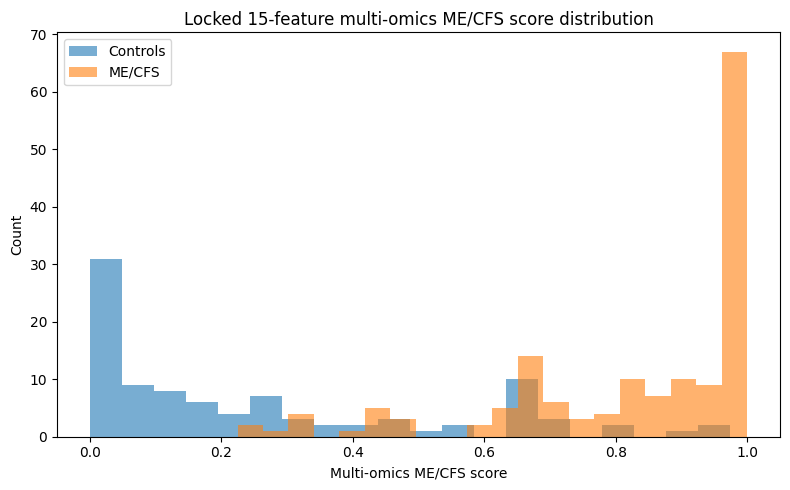

In [21]:
# =========================
# MULTI-OMICS ME/CFS SCORE + HISTOGRAM
# =========================

import matplotlib.pyplot as plt
import pandas as pd

# Fit final multi-omics model on all available multi-omics data
multi_score_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        C=1.0,
        max_iter=5000,
        random_state=42
    ))
])

multi_score_model.fit(X_multi[MULTIOMICS_PANEL], y_multi)

multi_scores = multi_score_model.predict_proba(
    X_multi[MULTIOMICS_PANEL]
)[:, 1]

multi_score_df = pd.DataFrame({
    "participant_id": X_multi.index,
    "label": y_multi.values,
    "multiomics_score": multi_scores
})

display(multi_score_df.head())

# Save
multi_score_df.to_csv(
    f"{OUT_DIR}/multiomics_mecfs_scores.csv",
    index=False
)

# Plot same colors as before
plt.figure(figsize=(8,5))

plt.hist(
    multi_score_df.loc[multi_score_df["label"] == 0, "multiomics_score"],
    bins=20,
    alpha=0.6,
    label="Controls"
)

plt.hist(
    multi_score_df.loc[multi_score_df["label"] == 1, "multiomics_score"],
    bins=20,
    alpha=0.6,
    label="ME/CFS"
)

plt.xlabel("Multi-omics ME/CFS score")
plt.ylabel("Count")
plt.title("Locked 15-feature multi-omics ME/CFS score distribution")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/multiomics_score_distribution.png", dpi=300)
plt.show()

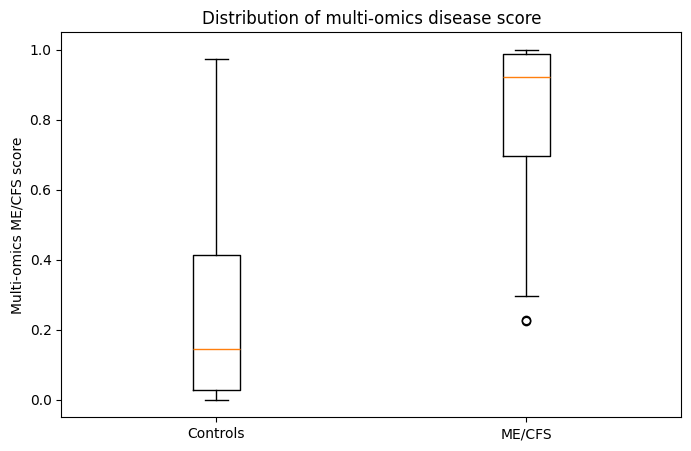

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(
    [
        multi_score_df.loc[multi_score_df["label"] == 0, "multiomics_score"],
        multi_score_df.loc[multi_score_df["label"] == 1, "multiomics_score"]
    ],
    labels=["Controls", "ME/CFS"]
)

plt.ylabel("Multi-omics ME/CFS score")
plt.title("Distribution of multi-omics disease score")
plt.show()

In [23]:
from scipy.stats import mannwhitneyu

u, p = mannwhitneyu(
    multi_score_df.loc[multi_score_df["label"] == 0, "multiomics_score"],
    multi_score_df.loc[multi_score_df["label"] == 1, "multiomics_score"]
)

print("p =", p)

p = 2.4140005702896685e-31


In [26]:
# =========================
# SAVE BOTH SCORES TOGETHER
# =========================

combined_scores = (
    score_df[["participant_id", "label", "mecfs_score"]]
    .rename(columns={"score": "metabolite_score"})
    .merge(
        multi_score_df[["participant_id", "multiomics_score"]],
        on="participant_id",
        how="outer"
    )
)

display(combined_scores.head())

combined_scores.to_csv(
    "../../output/mecfs_disease_scores.csv",
    index=False
)

print("Saved:", "../../output/mecfs_disease_scores.csv")
print("Shape:", combined_scores.shape)

,participant_id,label,mecfs_score,multiomics_score
0,SAM000269,1.0,0.636568,0.446210
1,SAM000268,1.0,0.740155,0.308120
2,SAM000266,1.0,0.516147,0.227576
3,SAM000257,0.0,0.100672,0.021972
4,SAM000260,1.0,0.868054,0.811688


Saved: ../../output/mecfs_disease_scores.csv
Shape: (249, 4)


In [28]:
print(
    "Correlation:",
    combined_scores["mecfs_score"].corr(
        combined_scores["multiomics_score"]
    )
)

Correlation: 0.8211142348629276


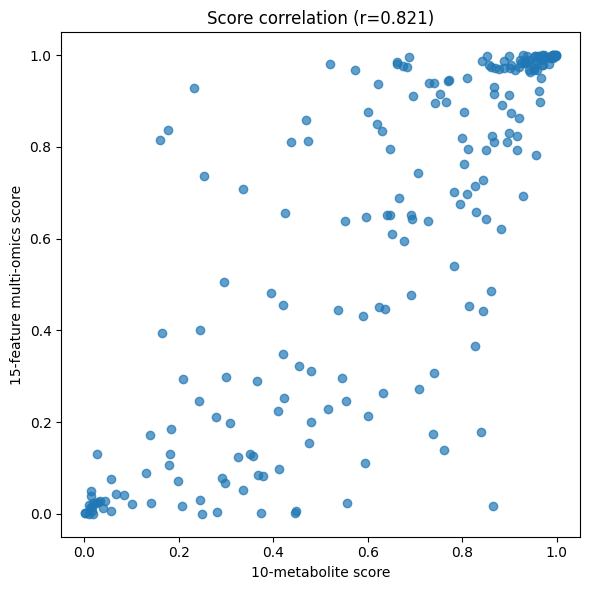

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    combined_scores["mecfs_score"],
    combined_scores["multiomics_score"],
    alpha=0.7
)

plt.xlabel("10-metabolite score")
plt.ylabel("15-feature multi-omics score")
plt.title(
    f"Score correlation (r={combined_scores['mecfs_score'].corr(combined_scores['multiomics_score']):.3f})"
)

plt.tight_layout()
plt.show()

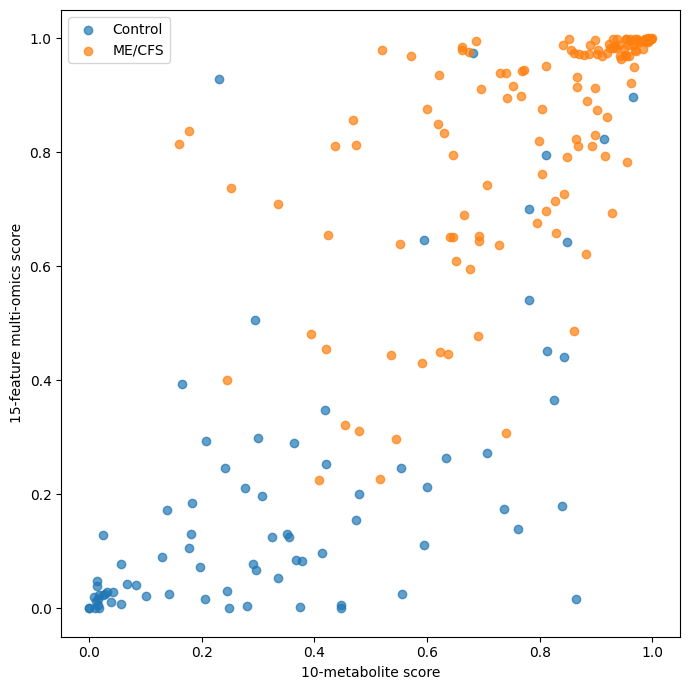

In [30]:
plt.figure(figsize=(7,7))

for label, color, name in [
    (0, "tab:blue", "Control"),
    (1, "tab:orange", "ME/CFS")
]:
    
    tmp = combined_scores[
        combined_scores["label"] == label
    ]
    
    plt.scatter(
        tmp["mecfs_score"],
        tmp["multiomics_score"],
        alpha=0.7,
        label=name
    )

plt.xlabel("10-metabolite score")
plt.ylabel("15-feature multi-omics score")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
combined_scores["delta"] = (
    combined_scores["multiomics_score"]
    - combined_scores["mecfs_score"]
)

combined_scores.sort_values(
    "delta",
    ascending=False
).head(20)

,participant_id,label,mecfs_score,multiomics_score,delta
16,SAM000234,0.0,0.231755,0.928598,0.696844
187,SAM000475,1.0,0.177370,0.837621,0.660251
115,SAM000276,1.0,0.160067,0.814754,0.654687
97,SAM000346,1.0,0.252237,0.737130,0.484894
102,SAM000318,1.0,0.520902,0.980560,0.459658
60,SAM000383,1.0,0.572223,0.968611,0.396388
113,SAM000299,1.0,0.468815,0.857733,0.388919
193,SAM000484,1.0,0.436808,0.810463,0.373655
164,SAM000462,1.0,0.336162,0.708983,0.372820
165,SAM000463,1.0,0.473576,0.813025,0.339449


In [32]:
combined_scores.sort_values(
    "delta",
    ascending=True
).head(20)

,participant_id,label,mecfs_score,multiomics_score,delta
152,SAM000390,0.0,0.865037,0.016602,-0.848434
138,SAM000426,0.0,0.839516,0.179306,-0.660211
176,SAM000445,0.0,0.762190,0.138707,-0.623483
131,SAM000427,0.0,0.737252,0.174781,-0.562471
124,SAM000428,0.0,0.556048,0.024228,-0.531821
184,SAM000490,0.0,0.594031,0.110998,-0.483033
140,SAM000417,0.0,0.826070,0.366224,-0.459845
66,SAM000347,0.0,0.446709,0.000911,-0.445798
85,SAM000325,0.0,0.448088,0.005539,-0.442548
56,SAM000382,0.0,0.707269,0.272021,-0.435247


In [33]:
print(
    pd.crosstab(
        combined_scores["label"],
        np.sign(combined_scores["delta"])
    )
)

delta  -1.0   1.0
label            
0.0      63    16
1.0      37    98


In [34]:
combined_scores.groupby("label")["delta"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0.0,79.0,-0.146549,0.231903,-0.848434,-0.282707,-0.078700,-0.001743,0.696844
1.0,135.0,0.047709,0.171633,-0.432035,-0.033549,0.022193,0.101480,0.660251


In [35]:
# ============================================================
# FINAL OVERFITTING / ROBUSTNESS CHECK FOR LOCKED PANELS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

N_SPLITS = 500

results = []

for model_name, X_data, y_data, panel in [

    ("10_metabolite",
     X_panel,
     y,
     LOCKED_PANEL),

    ("15_multiomics",
     X_multi,
     y_multi,
     MULTIOMICS_PANEL)

]:

    aucs = []

    for seed in range(N_SPLITS):

        X_train, X_test, y_train, y_test = train_test_split(
            X_data[panel],
            y_data,
            test_size=0.20,
            stratify=y_data,
            random_state=seed
        )

        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("logreg", LogisticRegression(
                penalty="l2",
                solver="liblinear",
                max_iter=5000,
                random_state=seed
            ))
        ])

        pipe.fit(X_train, y_train)

        probs = pipe.predict_proba(X_test)[:, 1]

        aucs.append(
            roc_auc_score(y_test, probs)
        )

    aucs = np.array(aucs)

    results.append({
        "model": model_name,
        "mean_auc": aucs.mean(),
        "median_auc": np.median(aucs),
        "std_auc": aucs.std(),
        "min_auc": aucs.min(),
        "max_auc": aucs.max(),
        "q05": np.quantile(aucs, 0.05),
        "q25": np.quantile(aucs, 0.25),
        "q75": np.quantile(aucs, 0.75),
        "q95": np.quantile(aucs, 0.95)
    })

    print(f"\n===== {model_name} =====")
    print(f"Mean AUC   : {aucs.mean():.3f}")
    print(f"Median AUC : {np.median(aucs):.3f}")
    print(f"Std AUC    : {aucs.std():.3f}")
    print(f"Min AUC    : {aucs.min():.3f}")
    print(f"Max AUC    : {aucs.max():.3f}")
    print(f"5th pct    : {np.quantile(aucs,0.05):.3f}")
    print(f"95th pct   : {np.quantile(aucs,0.95):.3f}")

summary = pd.DataFrame(results)

print("\n===== ROBUSTNESS SUMMARY =====")
display(summary)


===== 10_metabolite =====
Mean AUC   : 0.859
Median AUC : 0.861
Std AUC    : 0.056
Min AUC    : 0.667
Max AUC    : 0.981
5th pct    : 0.757
95th pct   : 0.942

===== 15_multiomics =====
Mean AUC   : 0.906
Median AUC : 0.908
Std AUC    : 0.039
Min AUC    : 0.767
Max AUC    : 0.993
5th pct    : 0.834
95th pct   : 0.966

===== ROBUSTNESS SUMMARY =====


,model,mean_auc,median_auc,std_auc,min_auc,max_auc,q05,q25,q75,q95
0,10_metabolite,0.859014,0.861111,0.055981,0.666667,0.981481,0.756944,0.823495,0.900463,0.942130
1,15_multiomics,0.906263,0.908319,0.039164,0.766553,0.993209,0.834423,0.879457,0.933998,0.966087


In [38]:
# =========================
# CLEAN FINAL EXPORT FOLDER — CURRENT NOTEBOOK VARIABLES
# =========================

import os
import pandas as pd
import numpy as np

FINAL_DIR = "../../output/FINAL_MECFS_SIGNATURE_EXPORT"
os.makedirs(FINAL_DIR, exist_ok=True)

# 1. Locked 10-metabolite panel
pd.DataFrame({
    "rank": range(1, len(LOCKED_PANEL) + 1),
    "feature": LOCKED_PANEL,
    "modality": "metabolite"
}).to_csv(f"{FINAL_DIR}/01_locked_10_metabolite_panel.csv", index=False)

# 2. Locked 15-feature multi-omics panel
pd.DataFrame({
    "rank": range(1, len(MULTIOMICS_PANEL) + 1),
    "feature": MULTIOMICS_PANEL,
    "modality": [
        f.split("__")[0] if "__" in f else "metadata"
        for f in MULTIOMICS_PANEL
    ]
}).to_csv(f"{FINAL_DIR}/02_locked_15_multiomics_panel.csv", index=False)

# 3. Subject scores
combined_scores.to_csv(
    f"{FINAL_DIR}/03_subject_scores_10metab_15multiomics.csv",
    index=False
)

# 4. Multi-omics consensus frequencies
multi_stability.to_csv(
    f"{FINAL_DIR}/04_multiomics_consensus_frequencies.csv",
    index=False
)

# 5. Multi-omics panel-size CV
panel_results_df.to_csv(
    f"{FINAL_DIR}/05_multiomics_panel_size_cv_results.csv",
    index=False
)

# 6. Multi-omics coefficients
multi_coef.rename("coefficient").reset_index().rename(
    columns={"index": "feature"}
).to_csv(
    f"{FINAL_DIR}/06_locked_15_multiomics_coefficients.csv",
    index=False
)

# 7. Multi-omics robustness summary
multi_summary.to_csv(
    f"{FINAL_DIR}/07_multiomics_robustness_summary.csv",
    index=False
)

# 8. Apples-to-apples model comparison
comparison_df.to_csv(
    f"{FINAL_DIR}/08_10metab_vs_15multiomics_repeated_split_comparison.csv",
    index=False
)

# 9. Final robustness summary from 500 splits
summary.to_csv(
    f"{FINAL_DIR}/09_final_500split_robustness_summary.csv",
    index=False
)

# 10. Score delta table
delta_table = combined_scores.copy()
delta_table["delta"] = (
    delta_table["multiomics_score"] - delta_table["mecfs_score"]
)

delta_table.to_csv(
    f"{FINAL_DIR}/10_score_delta_table.csv",
    index=False
)

# 11. Score correlation summary
score_corr = combined_scores["mecfs_score"].corr(
    combined_scores["multiomics_score"]
)

pd.DataFrame([{
    "score_correlation": score_corr
}]).to_csv(
    f"{FINAL_DIR}/11_score_correlation_summary.csv",
    index=False
)

print("Saved clean export folder:")
print(FINAL_DIR)

print("\nFiles saved:")
for f in sorted(os.listdir(FINAL_DIR)):
    print("-", f)

Saved clean export folder:
../../output/FINAL_MECFS_SIGNATURE_EXPORT

Files saved:
- 01_locked_10_metabolite_panel.csv
- 02_locked_15_multiomics_panel.csv
- 03_subject_scores_10metab_15multiomics.csv
- 04_multiomics_consensus_frequencies.csv
- 05_multiomics_panel_size_cv_results.csv
- 06_locked_15_multiomics_coefficients.csv
- 07_multiomics_robustness_summary.csv
- 08_10metab_vs_15multiomics_repeated_split_comparison.csv
- 09_final_500split_robustness_summary.csv
- 10_score_delta_table.csv
- 11_score_correlation_summary.csv


In [39]:
# =========================
# PRINT MULTI-OMICS FORMULA
# =========================

intercept = final_multi_model.named_steps["logreg"].intercept_[0]

coefs = pd.Series(
    final_multi_model.named_steps["logreg"].coef_[0],
    index=MULTIOMICS_PANEL
)

print("\n===== MULTI-OMICS ME/CFS SCORE FORMULA =====\n")

print(f"logit(p) = {intercept:.6f}")

for feature, coef in coefs.items():
    sign = "+" if coef >= 0 else "-"
    print(f" {sign} {abs(coef):.6f} * ({feature})")

print("\nProbability(ME/CFS) = 1 / (1 + exp(-logit(p)))")


===== MULTI-OMICS ME/CFS SCORE FORMULA =====

logit(p) = 1.075533
 + 0.770867 * (quest__Vitamin B12)
 + 0.898680 * (species__Dysosmobacter_welbionis)
 + 0.266656 * (metab__1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6))
 + 0.633110 * (metab__N-palmitoyl-sphingosine (d18:1/16:0))
 + 0.827285 * (metab__N-acetylglutamate)
 - 0.559898 * (metab__3-(4-hydroxyphenyl)lactate)
 - 1.011271 * (species__GGB1266_SGB1699)
 - 0.629563 * (metab__1-methylurate)
 + 0.979363 * (metab__N4-acetylcytidine)
 + 0.892619 * (metab__sphingomyelin (d18:1/24:1, d18:2/24:0)*)
 + 0.462149 * (metab__N-acetylglucosamine/N-acetylgalactosamine)
 - 1.019425 * (metab__vanillylmandelate (VMA))
 - 0.920002 * (species__Phocaeicola_plebeius)
 + 0.779194 * (immune_res__% CD4+ CD161+ Va7.2- d6)
 + 0.873070 * (immune_pct__CD8+ DN+ MAIT % RO- CD27- d0)

Probability(ME/CFS) = 1 / (1 + exp(-logit(p)))


Real AUC: 0.8251

===== PERMUTATION TEST =====
Real AUC: 0.8251
Null mean AUC: 0.5094
Null std AUC: 0.1277
Permutation p-value: 0.001998001998001998


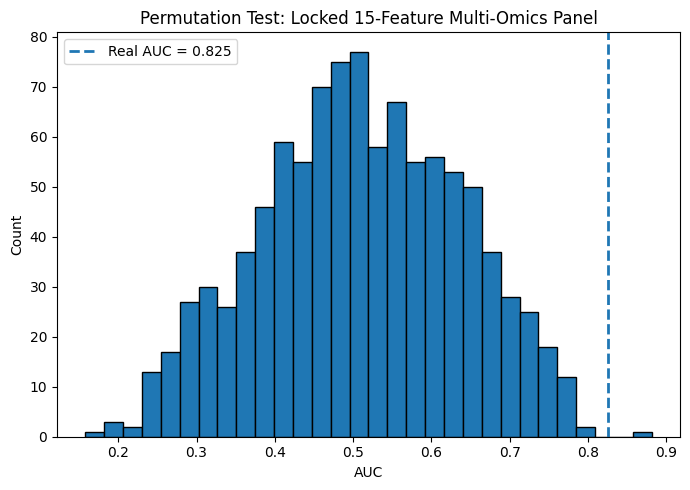

In [40]:
# ============================================================
# PERMUTATION TEST — LOCKED 15-FEATURE MULTI-OMICS PANEL
# ============================================================

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

N_PERMUTATIONS = 1000
RANDOM_STATE = 42

# ------------------------------------------------
# Real model performance
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_multi[MULTIOMICS_PANEL],
    y_multi,
    test_size=0.20,
    stratify=y_multi,
    random_state=RANDOM_STATE
)

real_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

real_model.fit(X_train, y_train)

real_probs = real_model.predict_proba(X_test)[:, 1]
real_auc = roc_auc_score(y_test, real_probs)

print("Real AUC:", round(real_auc, 4))

# ------------------------------------------------
# Permutation null distribution
# ------------------------------------------------

perm_aucs = []

for i in range(N_PERMUTATIONS):

    y_perm = np.random.permutation(y_train)

    perm_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=5000
        ))
    ])

    perm_model.fit(X_train, y_perm)

    perm_probs = perm_model.predict_proba(X_test)[:, 1]

    perm_auc = roc_auc_score(
        y_test,
        perm_probs
    )

    perm_aucs.append(perm_auc)

perm_aucs = np.array(perm_aucs)

# ------------------------------------------------
# p-value
# ------------------------------------------------

p_value = (
    np.sum(perm_aucs >= real_auc) + 1
) / (
    N_PERMUTATIONS + 1
)

print("\n===== PERMUTATION TEST =====")
print("Real AUC:", round(real_auc, 4))
print("Null mean AUC:", round(perm_aucs.mean(), 4))
print("Null std AUC:", round(perm_aucs.std(), 4))
print("Permutation p-value:", p_value)

# ------------------------------------------------
# Plot
# ------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.hist(
    perm_aucs,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    real_auc,
    linestyle="--",
    linewidth=2,
    label=f"Real AUC = {real_auc:.3f}"
)

plt.xlabel("AUC")
plt.ylabel("Count")
plt.title("Permutation Test: Locked 15-Feature Multi-Omics Panel")
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
coef_10 = pd.Series(
    score_model.named_steps["logreg"].coef_[0],
    index=LOCKED_PANEL
)

coef_10_df = (
    coef_10
    .rename("coefficient")
    .reset_index()
    .rename(columns={"index": "feature"})
)

coef_10_df.to_csv(
    f"{FINAL_DIR}/10_metabolite_coefficients.csv",
    index=False
)

display(coef_10_df)

,feature,coefficient
0,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),0.437453
1,N-acetylglutamate,0.958517
2,N4-acetylcytidine,0.844434
3,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",0.440304
4,1-methylurate,-0.424576
5,N-palmitoyl-sphingosine (d18:1/16:0),0.463581
6,3-(4-hydroxyphenyl)lactate,-0.800895
7,N-acetylglucosamine/N-acetylgalactosamine,0.282679
8,vanillylmandelate (VMA),-0.775570
9,4-vinylguaiacol sulfate,-0.279517


In [42]:
# ============================================================
# CREATE CLEAN FINAL EXPORT FOLDER
# ============================================================

from pathlib import Path
import os

# Creates folder OUTSIDE your project/output folders
FINAL_DIR = Path.cwd().parent / "MECFS_FINAL_SIGNATURES"

FINAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Created:")
print(FINAL_DIR)

# ============================================================
# SAVE CORE ARTIFACTS
# ============================================================

# 1. Locked 10 metabolite panel
pd.DataFrame({
    "feature": LOCKED_PANEL
}).to_csv(
    FINAL_DIR / "01_locked_10_metabolite_panel.csv",
    index=False
)

# 2. Locked 15 multi-omics panel
pd.DataFrame({
    "feature": MULTIOMICS_PANEL
}).to_csv(
    FINAL_DIR / "02_locked_15_multiomics_panel.csv",
    index=False
)

# 3. Subject scores
combined_scores.to_csv(
    FINAL_DIR / "03_subject_scores.csv",
    index=False
)

# 4. 10-metabolite coefficients
coef_10 = pd.Series(
    score_model.named_steps["logreg"].coef_[0],
    index=LOCKED_PANEL
)

coef_10.rename("coefficient").reset_index().rename(
    columns={"index": "feature"}
).to_csv(
    FINAL_DIR / "04_10_metabolite_coefficients.csv",
    index=False
)

# 5. 10-metabolite intercept
pd.DataFrame({
    "intercept": [
        score_model.named_steps["logreg"].intercept_[0]
    ]
}).to_csv(
    FINAL_DIR / "05_10_metabolite_intercept.csv",
    index=False
)

# 6. 15-feature coefficients
multi_coef.rename("coefficient").reset_index().rename(
    columns={"index": "feature"}
).to_csv(
    FINAL_DIR / "06_15_multiomics_coefficients.csv",
    index=False
)

# 7. 15-feature intercept
pd.DataFrame({
    "intercept": [
        final_multi_model.named_steps["logreg"].intercept_[0]
    ]
}).to_csv(
    FINAL_DIR / "07_15_multiomics_intercept.csv",
    index=False
)

# 8. Robustness summary
summary.to_csv(
    FINAL_DIR / "08_robustness_summary.csv",
    index=False
)

# 9. Score correlation
pd.DataFrame({
    "correlation": [
        combined_scores["mecfs_score"].corr(
            combined_scores["multiomics_score"]
        )
    ]
}).to_csv(
    FINAL_DIR / "09_score_correlation.csv",
    index=False
)

# 10. Delta table
delta_table = combined_scores.copy()
delta_table["delta"] = (
    delta_table["multiomics_score"]
    - delta_table["mecfs_score"]
)

delta_table.to_csv(
    FINAL_DIR / "10_score_delta_table.csv",
    index=False
)

print("\nSaved files:")
for f in sorted(os.listdir(FINAL_DIR)):
    print("-", f)

Created:
c:\Users\rohan\OneDrive\Desktop\ME-CFS\src\MECFS_FINAL_SIGNATURES

Saved files:
- 01_locked_10_metabolite_panel.csv
- 02_locked_15_multiomics_panel.csv
- 03_subject_scores.csv
- 04_10_metabolite_coefficients.csv
- 05_10_metabolite_intercept.csv
- 06_15_multiomics_coefficients.csv
- 07_15_multiomics_intercept.csv
- 08_robustness_summary.csv
- 09_score_correlation.csv
- 10_score_delta_table.csv


In [43]:
# ============================================================
# REMOVE ALL MICROBIOME FEATURES FROM 15-PANEL
# ============================================================

NO_GUT_PANEL = [
    f for f in MULTIOMICS_PANEL
    if not f.startswith("species__")
]

print("Original panel size:", len(MULTIOMICS_PANEL))
print("No-gut panel size:", len(NO_GUT_PANEL))

print("\nRemoved:")
for f in MULTIOMICS_PANEL:
    if f.startswith("species__"):
        print("-", f)

print("\nRemaining features:")
for f in NO_GUT_PANEL:
    print("-", f)

Original panel size: 15
No-gut panel size: 12

Removed:
- species__Dysosmobacter_welbionis
- species__GGB1266_SGB1699
- species__Phocaeicola_plebeius

Remaining features:
- quest__Vitamin B12
- metab__1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)
- metab__N-palmitoyl-sphingosine (d18:1/16:0)
- metab__N-acetylglutamate
- metab__3-(4-hydroxyphenyl)lactate
- metab__1-methylurate
- metab__N4-acetylcytidine
- metab__sphingomyelin (d18:1/24:1, d18:2/24:0)*
- metab__N-acetylglucosamine/N-acetylgalactosamine
- metab__vanillylmandelate (VMA)
- immune_res__% CD4+ CD161+ Va7.2- d6
- immune_pct__CD8+ DN+ MAIT % RO- CD27- d0


In [44]:
# ============================================================
# 500-SPLIT ROBUSTNESS FOR NO-GUT PANEL
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np

nogut_aucs = []

for seed in range(500):

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_multi[NO_GUT_PANEL],
        y_multi,
        test_size=0.20,
        stratify=y_multi,
        random_state=seed
    )

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
            random_state=seed
        ))
    ])

    model.fit(X_tr, y_tr)

    probs = model.predict_proba(X_te)[:, 1]

    nogut_aucs.append(
        roc_auc_score(y_te, probs)
    )

nogut_aucs = np.array(nogut_aucs)

print("\n===== NO-GUT PANEL =====")
print("Mean AUC :", nogut_aucs.mean())
print("Median   :", np.median(nogut_aucs))
print("Std      :", nogut_aucs.std())
print("5th pct  :", np.quantile(nogut_aucs, 0.05))
print("95th pct :", np.quantile(nogut_aucs, 0.95))


===== NO-GUT PANEL =====
Mean AUC : 0.863402376910017
Median   : 0.8629032258064516
Std      : 0.04606403554826958
5th pct  : 0.7843803056027164
95th pct : 0.9355263157894737
